# X (formerly Twitter) Sentiment Analysis of U.S. Airlines 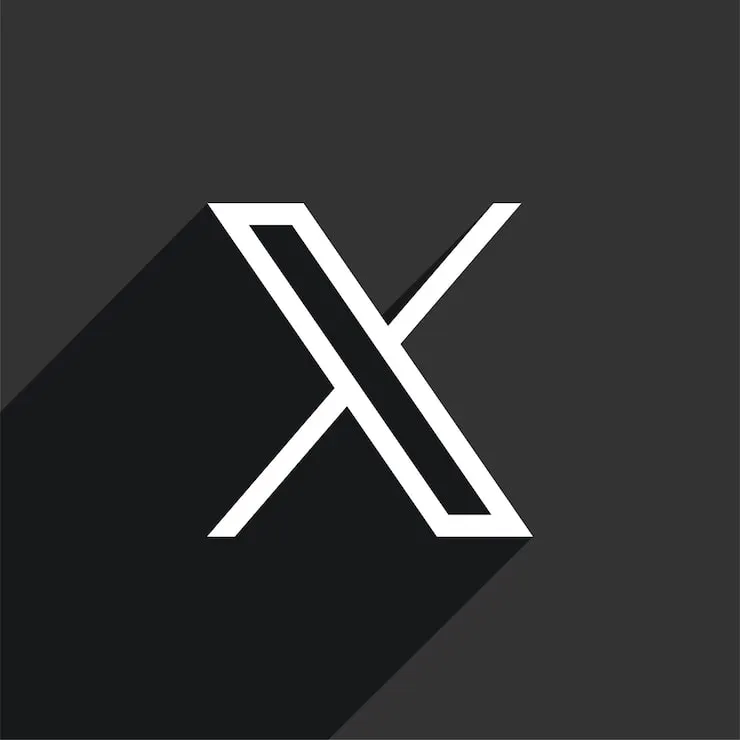
### Advanced NLP Pipeline — Classical ML + BERT Transformer

---

## 📋 Project Overview

This project builds an **end-to-end sentiment analysis system** capable 
of classifying airline customer tweets into three sentiment categories:
**Positive**, **Negative**, and **Neutral**.

It demonstrates two complete NLP approaches side by side — traditional 
Machine Learning with TF-IDF vectorization, and a state-of-the-art 
**BERT Transformer** fine-tuned on domain-specific data — allowing a 
direct, honest comparison between classical and deep learning methods.

---

## 🎯 Business Context

Airlines receive thousands of customer tweets daily. Manual review is 
impossible at scale. An automated sentiment classifier enables:

- **Real-time customer feedback monitoring**
- **Early detection of service failures** before they escalate
- **Routing negative tweets** to support teams automatically
- **Tracking sentiment trends** over time by airline, route, or issue type

---

## 📦 Dataset

| Property | Detail |
|---|---|
| **Source** | Twitter US Airline Sentiment — Kaggle |
| **Size** | ~14,000 tweets |
| **Period** | February 2015 |
| **Airlines** | United, Delta, American, Southwest, US Airways, Virgin America |
| **Target** | `airline_sentiment` → positive / negative / neutral |
| **Challenge** | Real messy text — slang, typos, @mentions, hashtags, URLs |

---

## ⚠️ Key Challenge — Class Imbalance

The dataset is heavily skewed toward negative sentiment — reflecting 
real-world behavior where unhappy customers tweet far more than 
satisfied ones. This imbalance must be handled carefully to avoid 
a model that simply predicts "negative" for everything.

---

## 🗺️ Pipeline

| Step | Description | Tools |
|---|---|---|
| 1 | Load & explore data | kagglehub, pandas |
| 2 | EDA — distributions, word clouds | matplotlib, wordcloud |
| 3 | Text cleaning & lemmatization | nltk, regex |
| 4 | Train/test split | sklearn |
| 5 | TF-IDF vectorization | TfidfVectorizer |
| 6 | Classical model comparison | LR, SVM, RF, XGBoost, NaiveBayes |
| 7 | Handle class imbalance | class_weight, SMOTE |
| 8 | Tune the winner | BayesSearchCV |
| 9 | Feature importance | Most influential words per sentiment |
| 10 | Error analysis | What does the model get wrong and why? |
| 11 | BERT fine-tuning | HuggingFace Transformers, PyTorch |
| 12 | Classical vs BERT comparison | Final scorecard |
| 13 | SHAP values | Model interpretability |
| 14 | End-to-end inference | Predict on raw new text |
| 15 | Export | joblib + HuggingFace save |
| 16 | Conclusion | Honest limitations & next steps |

---

## 🧰 Two Approaches Compared

### Approach 1 — Classical ML (TF-IDF + Sklearn)
Fast, interpretable, explainable. Treats text as a bag of words — 
word meaning and context are lost, but performance is surprisingly strong.

### Approach 2 — BERT Transformer (Deep Learning)
Slow to train but understands word meaning in context. "not good" and 
"good" are treated completely differently — a capability classical 
models fundamentally lack.

---

## 📐 Coding Standards

- All text cleaning applied **before** the split where safe
- Vectorization and modeling inside **pipelines** — no leakage
- Same `StratifiedKFold` CV strategy across **all** models
- Test

## 📊 Data Source

We load the Twitter US Airline Sentiment dataset directly from Kaggle 
using `kagglehub`. The dataset contains ~14,000 real customer tweets 
from February 2015 across 6 major US airlines.

> Source: [Twitter US Airline Sentiment dataset](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment)

#### 📥 Loading the Dataset

We read the located CSV into a pandas DataFrame — this is our raw, 
unprocessed dataset, straight from the Kaggle download.

In [11]:
%pip install pandas numpy matplotlib seaborn scikit-learn nltk jupyterlab transformers torch datasets wordcloud shap watermark imbalanced-learn xgboost kagglehub -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
# ============================================================
# 📦 DEPENDENCIES
# ============================================================

# ✅ Core
import os
import re
import warnings
import logging
import joblib
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore', category=UserWarning)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ✅ Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from wordcloud import WordCloud
plt.style.use('dark_background')

# ✅ Text Processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# ✅ Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# ✅ Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# ✅ Pipeline
from sklearn.pipeline import Pipeline

# ✅ Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score
)

# ✅ Validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_val_predict
)

print("✅ All dependencies loaded!")

✅ All dependencies loaded!


In [13]:
# Load the watermark extension to log the environment state
%reload_ext watermark

# Display professional metadata tracking our data engineering stack (NO SPACES after commas)
%watermark -a "Maykon - Twitter US Airline Sentiment Analysis 🐦 (Didn't find a blue bird!) " -d -u -v -p pandas,numpy,matplotlib,seaborn,scikit-learn,nltk,jupyterlab,transformers,torch,datasets,wordcloud,shap,watermark,imbalanced-learn,xgboost,kagglehub

Author: Maykon - Twitter US Airline Sentiment Analysis 🐦 (Didn't find a blue bird!) 

Last updated: 2026-09-08

Python implementation: CPython
Python version       : 3.13.7
IPython version      : 9.17.1

pandas          : 3.0.5
numpy           : 2.5.3
matplotlib      : 3.11.1
seaborn         : 0.13.2
scikit-learn    : 1.9.0
nltk            : 3.10.3
jupyterlab      : 4.6.3
transformers    : 5.16.1
torch           : 2.14.0
datasets        : 5.0.1
wordcloud       : 1.9.6
shap            : 0.52.0
watermark       : 2.6.0
imbalanced-learn: 0.14.2
xgboost         : 3.4.1
kagglehub       : 1.0.2



> OBS: This project was built with assistance from Claude (Anthropic) for 
> code review, debugging, and explanation throughout the notebook.

In [14]:
# --- AUTOMATED KAGGLE INGESTION ---
# Download the latest version of dataset
path = kagglehub.dataset_download("crowdflower/twitter-airline-sentiment")
print("🚀 Path to dataset files:", path)

🚀 Path to dataset files: C:\Users\LarTI\.cache\kagglehub\datasets\crowdflower\twitter-airline-sentiment\versions\4


In [15]:
# --- LOCATING AND READING THE CSV ---
# List out all files inside the downloaded repository path to spot the target file
all_files = os.listdir(path)
print("📂 Files discovered in directory:", all_files)

# Filter out all CSV files dynamically
csv_files = [file for file in all_files if file.endswith('.csv')]

if len(csv_files) == 0:
    raise FileNotFoundError("❌ Critical Error: No CSV files found in the downloaded folder!")
else:
    # Grab the primary CSV file found
    csv_filename = csv_files[0]
    full_csv_path = os.path.join(path, csv_filename)
    print(f"🎯 Target CSV located: {csv_filename}")

📂 Files discovered in directory: ['database.sqlite', 'Tweets.csv']
🎯 Target CSV located: Tweets.csv


In [16]:
# Ingest the dataset into a pandas DataFrame
df = pd.read_csv(full_csv_path)
print(f"✅ Dataset successfully loaded! Named 'df', Shape: {df.shape[0]} rows, {df.shape[1]} columns.")

✅ Dataset successfully loaded! Named 'df', Shape: 14640 rows, 15 columns.


In [17]:
# Display the first 5 records to see our column properties and labels
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [18]:
df.shape # (columns, rows)
print("Number of columns:", df.shape[1])
print("Number of rows:", df.shape[0])

Number of columns: 15
Number of rows: 14640


In [19]:
df.sample(15) # Random 15 rows

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
2332,569257540023951360,negative,1.0000,Late Flight,1.0000,United,NaN,gorgeousjack,NaN,0,@united we are sitting on the runway for 2 hou...,NaN,2015-02-21 14:09:08 -0800,GORGEOUS UNIVERSE,Quito
3541,568280611552681985,negative,0.6635,Customer Service Issue,0.3481,United,NaN,alafairburke,NaN,0,@united if guy on flight 1230 follows through ...,NaN,2015-02-18 21:27:10 -0800,New York,Quito
11854,567728017196457987,neutral,0.6379,NaN,0.0000,US Airways,NaN,laura_crom,NaN,0,@USAirways on your website and on your boards ...,NaN,2015-02-17 08:51:21 -0800,boston,Quito
1379,569749233344983040,negative,1.0000,Late Flight,0.6759,United,NaN,hilary33836700,NaN,0,@united Is flight 746 going to sit on the tarm...,NaN,2015-02-22 22:42:57 -0800,NaN,NaN
10240,569466525297590272,negative,1.0000,Customer Service Issue,0.6808,US Airways,NaN,mnorouzi,NaN,0,"@USAirways - what a disaster! Flight 3739, mis...","[39.05365524, -84.65487604]",2015-02-22 03:59:34 -0800,NaN,NaN
3016,568797413529538562,neutral,0.6582,NaN,0.0000,United,NaN,MrsHeyGil,NaN,0,@united traveling from FRA thru IAD to MCO tom...,NaN,2015-02-20 07:40:45 -0800,"Obersulzbach, Germany",Quito
4966,569598588378087426,negative,0.6700,Flight Attendant Complaints,0.3400,Southwest,NaN,JessicaTickle,NaN,0,@SouthwestAir now I'm so lucky for my forced g...,NaN,2015-02-22 12:44:20 -0800,CA & MI,Alaska
8464,568239189055176704,negative,1.0000,Late Flight,0.6544,Delta,NaN,JustRhinoceros,NaN,0,@JetBlue I want you to pay for my parking fee ...,NaN,2015-02-18 18:42:34 -0800,Saint Leo,Eastern Time (US & Canada)
3784,568128387576762370,negative,1.0000,Bad Flight,1.0000,United,NaN,Vic_Sutter,NaN,0,@united my plane sounds like a DJ scratching...,NaN,2015-02-18 11:22:17 -0800,Las Vegas,Hawaii
10064,569552945324273665,negative,1.0000,Customer Service Issue,1.0000,US Airways,NaN,MaryJoReed1,NaN,0,@USAirways WORST customer service ever!!!,NaN,2015-02-22 09:42:58 -0800,Indiana Girl,Indiana (East)


In [20]:
df.tail() #Displays the last 5 rows of the DataFrame df.

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)
14639,569587140490866689,neutral,0.6771,NaN,0.0000,American,NaN,daviddtwu,NaN,0,@AmericanAir we have 8 ppl so we need 2 know h...,NaN,2015-02-22 11:58:51 -0800,"dallas, TX",NaN
